In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ysy_plot_utils as ypu
import pandas as pd
import ruptures as rpt # 变点检测库

plt.rcParams.update(ypu.ysy_settings())

# 测试Ruptures

In [ ]:
# 加载数据
data_fall1 = pd.read_csv('data/1A下降.xls', encoding='latin1', sep='\t', skiprows=2, usecols=[0, 1], names=['R(V)', 'T(K)'])
signal = data_fall1['R(V)'].values # 信号

In [ ]:
# 变点检测
algo = rpt.Dynp(model="l2").fit(signal)
result = algo.predict(n_bkps=2)
print(result)

[320, 350, 964]


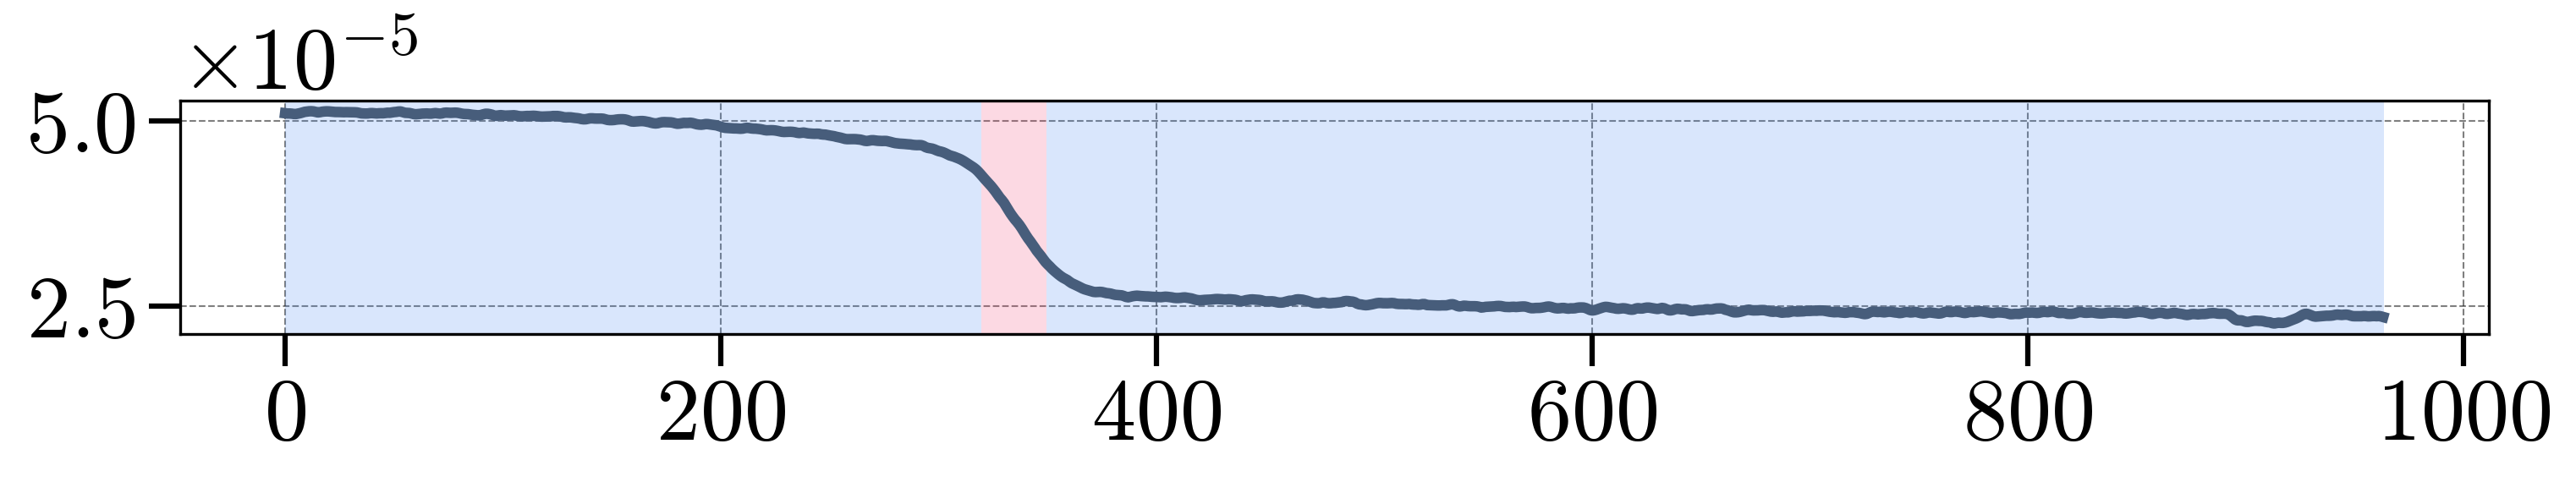

In [ ]:
# 快速绘制
rpt.display(signal, result)
plt.show()

In [ ]:
# 对应温度
T_values = data_fall1['T(K)'].values
print('Change Point :')
print('Start: ', T_values[320])
print('End: ', T_values[350])

Change Point :
Start:  86.4
End:  85.73


# 正式处理

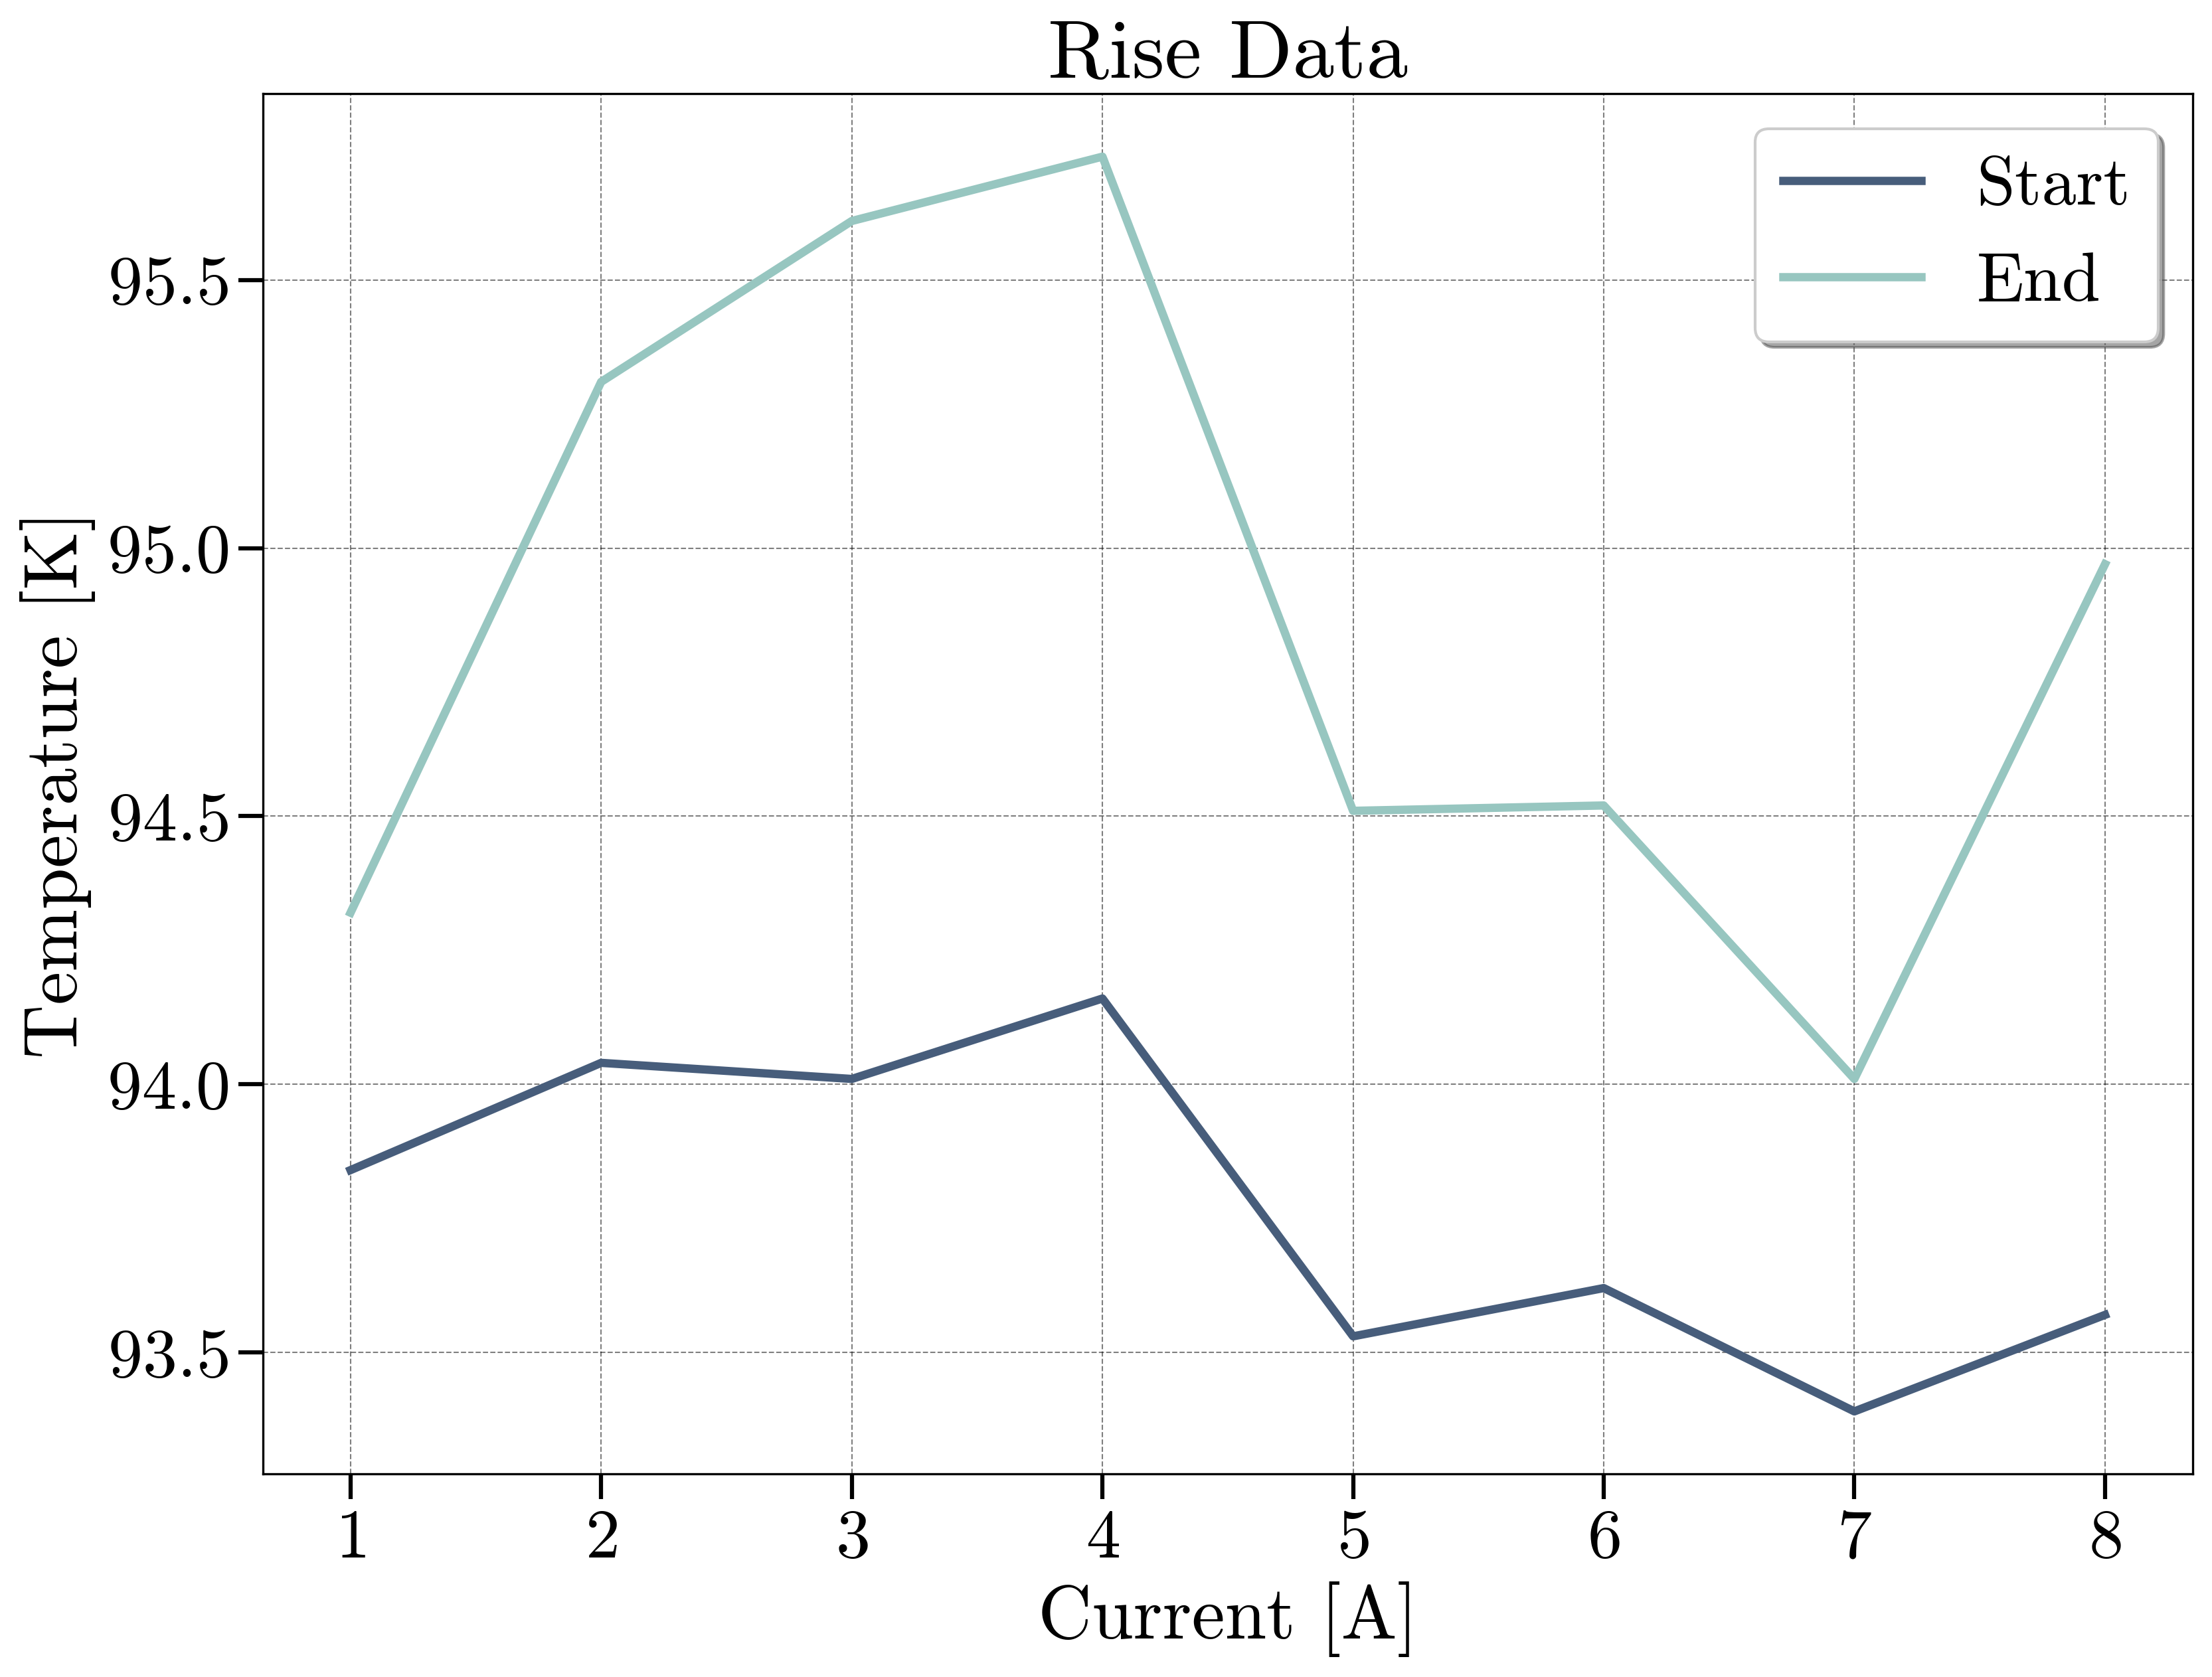

In [4]:
rise_data_list = []
for current in range(1, 9):
    rise_data_list.append(pd.read_csv('data/'+str(current)+'A上升.xls', encoding='latin1', sep='\t', skiprows=2, usecols=[0, 1], names=['R(V)', 'T(K)']))

rise_change_point = []
for rise_data in rise_data_list:
    algo = rpt.Dynp(model="l2").fit(rise_data['R(V)'].values)
    result = algo.predict(n_bkps=2)
    rise_change_point.append((rise_data['T(K)'].values[result[0]], rise_data['T(K)'].values[result[1]]))

rise_change_point = np.array(rise_change_point).T
current = np.array([1, 2, 3, 4, 5, 6, 7, 8])
ypu.plot(
    current, (rise_change_point[0], rise_change_point[1]), ('Start', 'End'), 
    'Rise Data', 'Current [A]', 'Temperature [K]'
)

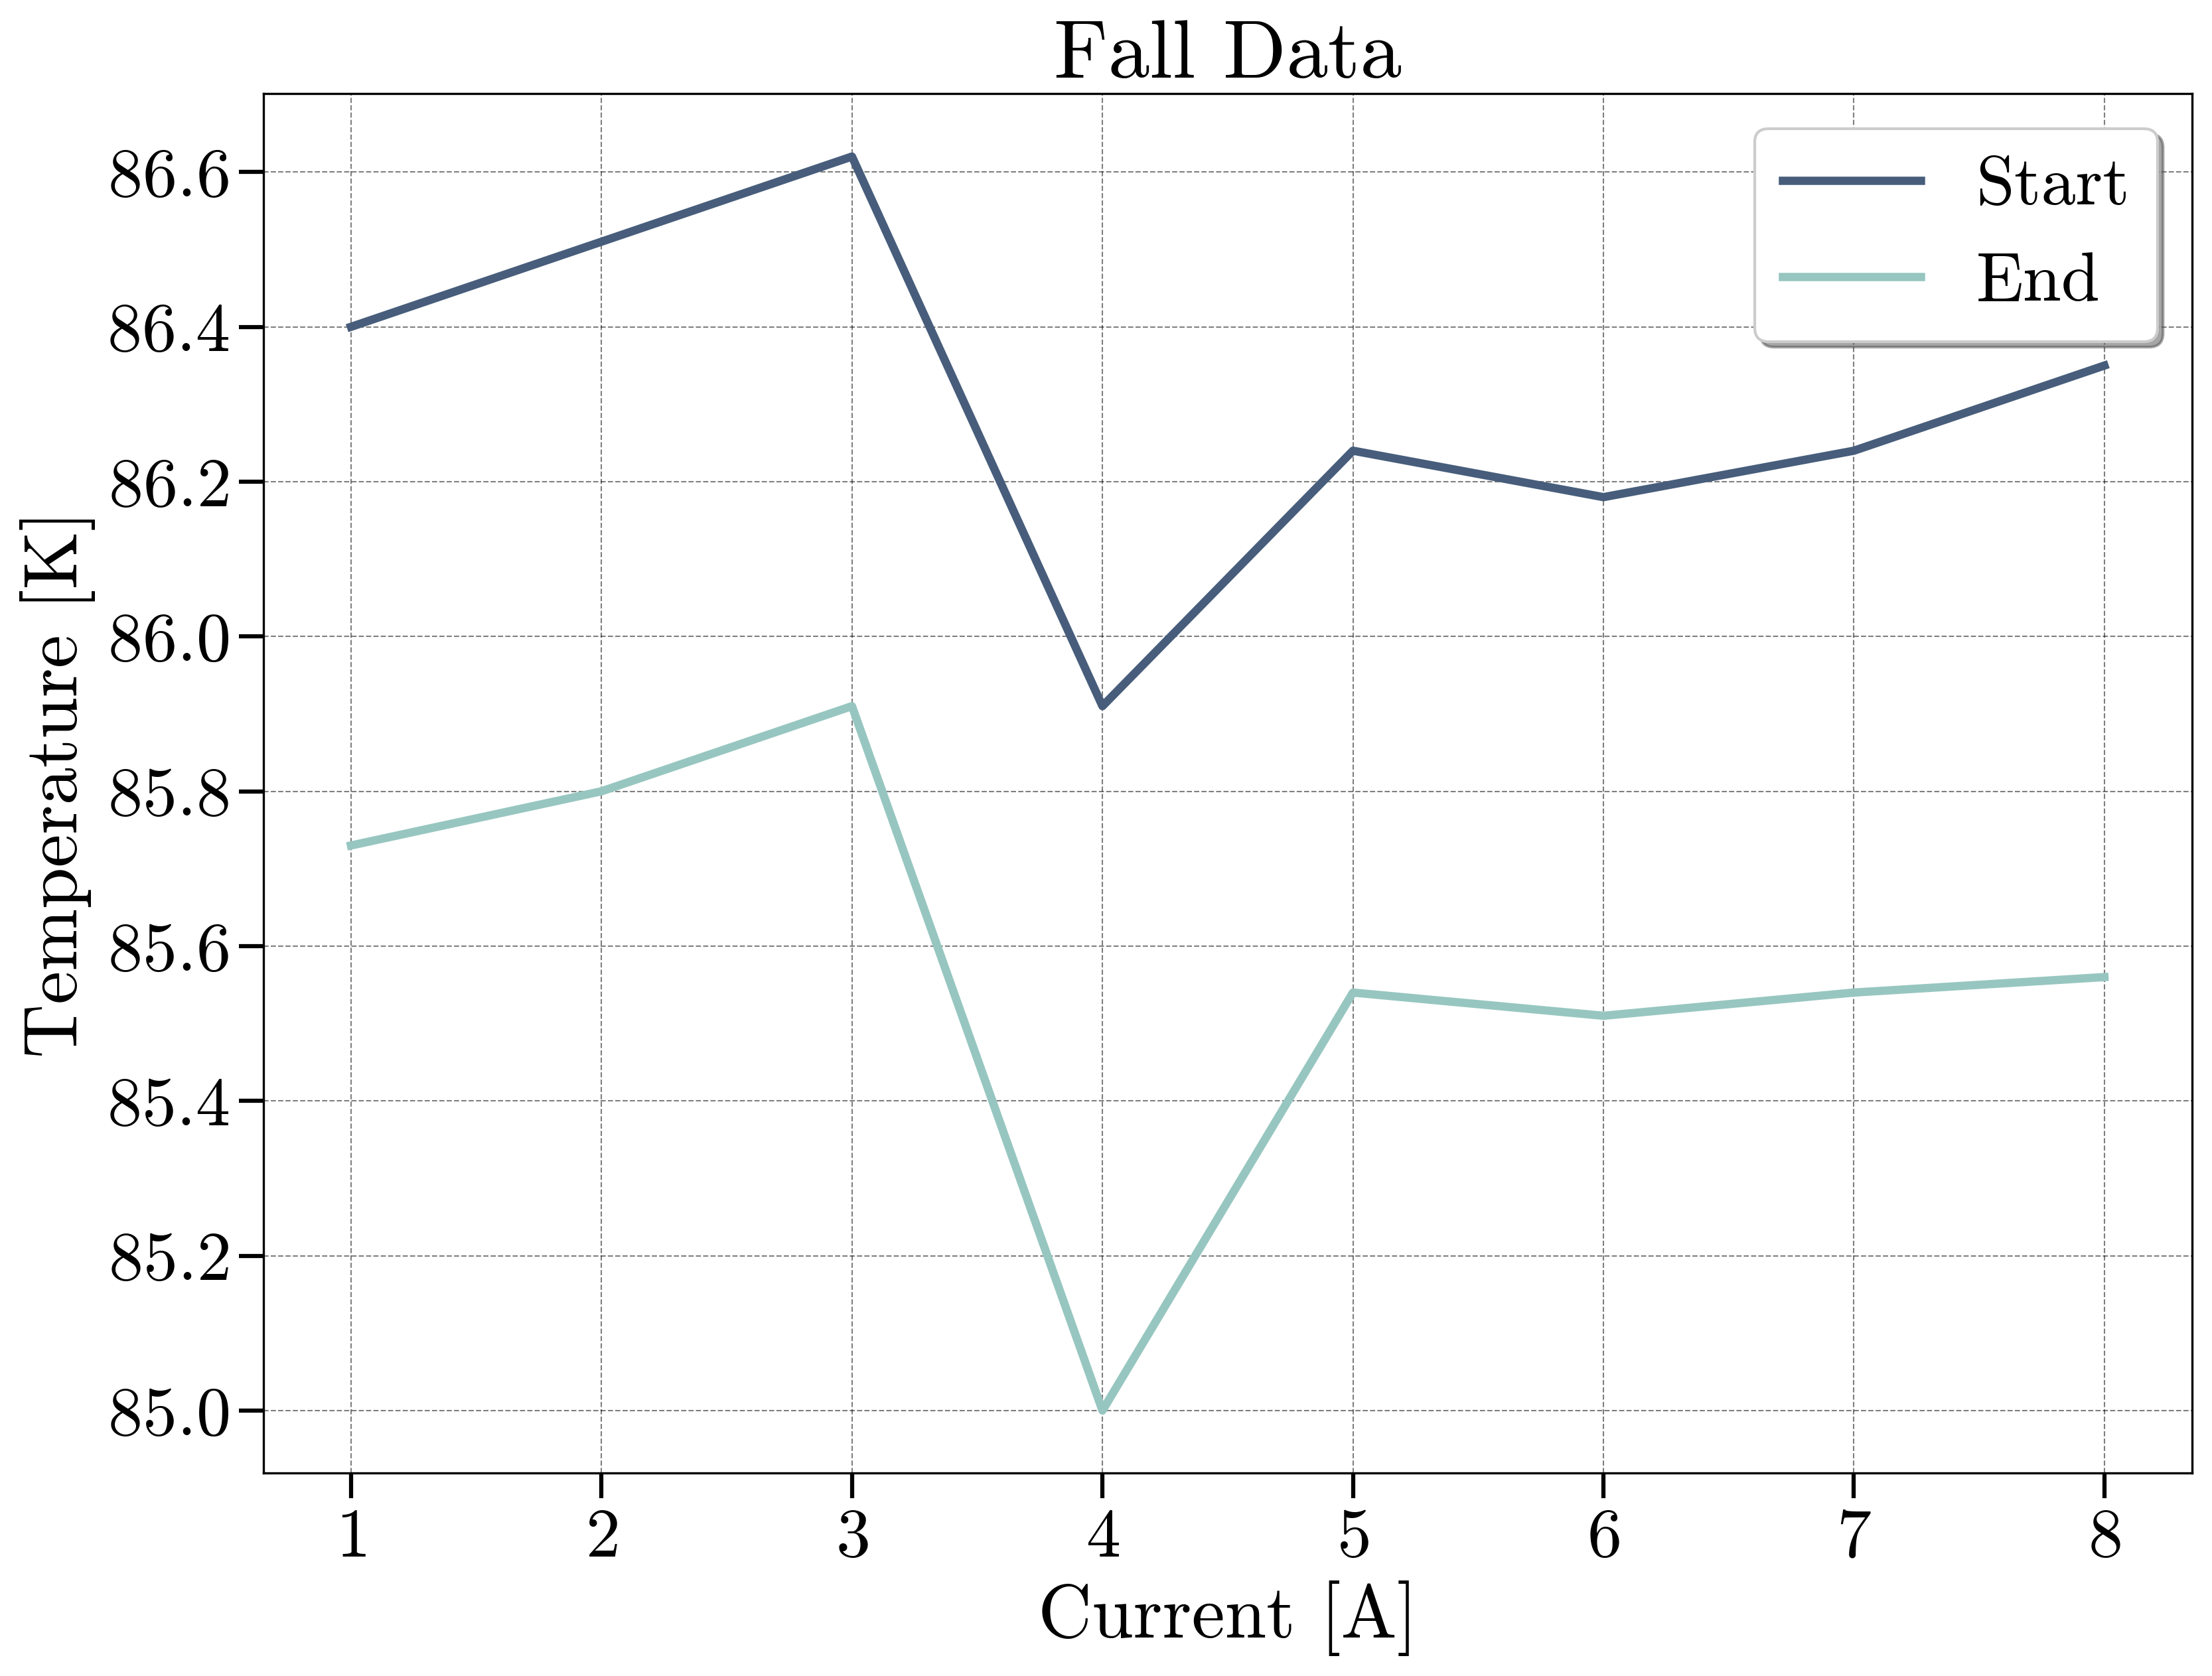

In [6]:
fall_data_list = []
for current in range(1, 9):
    fall_data_list.append(pd.read_csv('data/'+str(current)+'A下降.xls', encoding='latin1', sep='\t', skiprows=2, usecols=[0, 1], names=['R(V)', 'T(K)']))

fall_change_point = []
for fall_data in fall_data_list:
    algo = rpt.Dynp(model="l2").fit(fall_data['R(V)'].values)
    result = algo.predict(n_bkps=2)
    fall_change_point.append((fall_data['T(K)'].values[result[0]], fall_data['T(K)'].values[result[1]]))

fall_change_point = np.array(fall_change_point).T
current = np.array([1, 2, 3, 4, 5, 6, 7, 8])
ypu.plot(
    current, (fall_change_point[0], fall_change_point[1]), ('Start', 'End'), 
    'Fall Data', 'Current [A]', 'Temperature [K]'
)

# 转变温度？

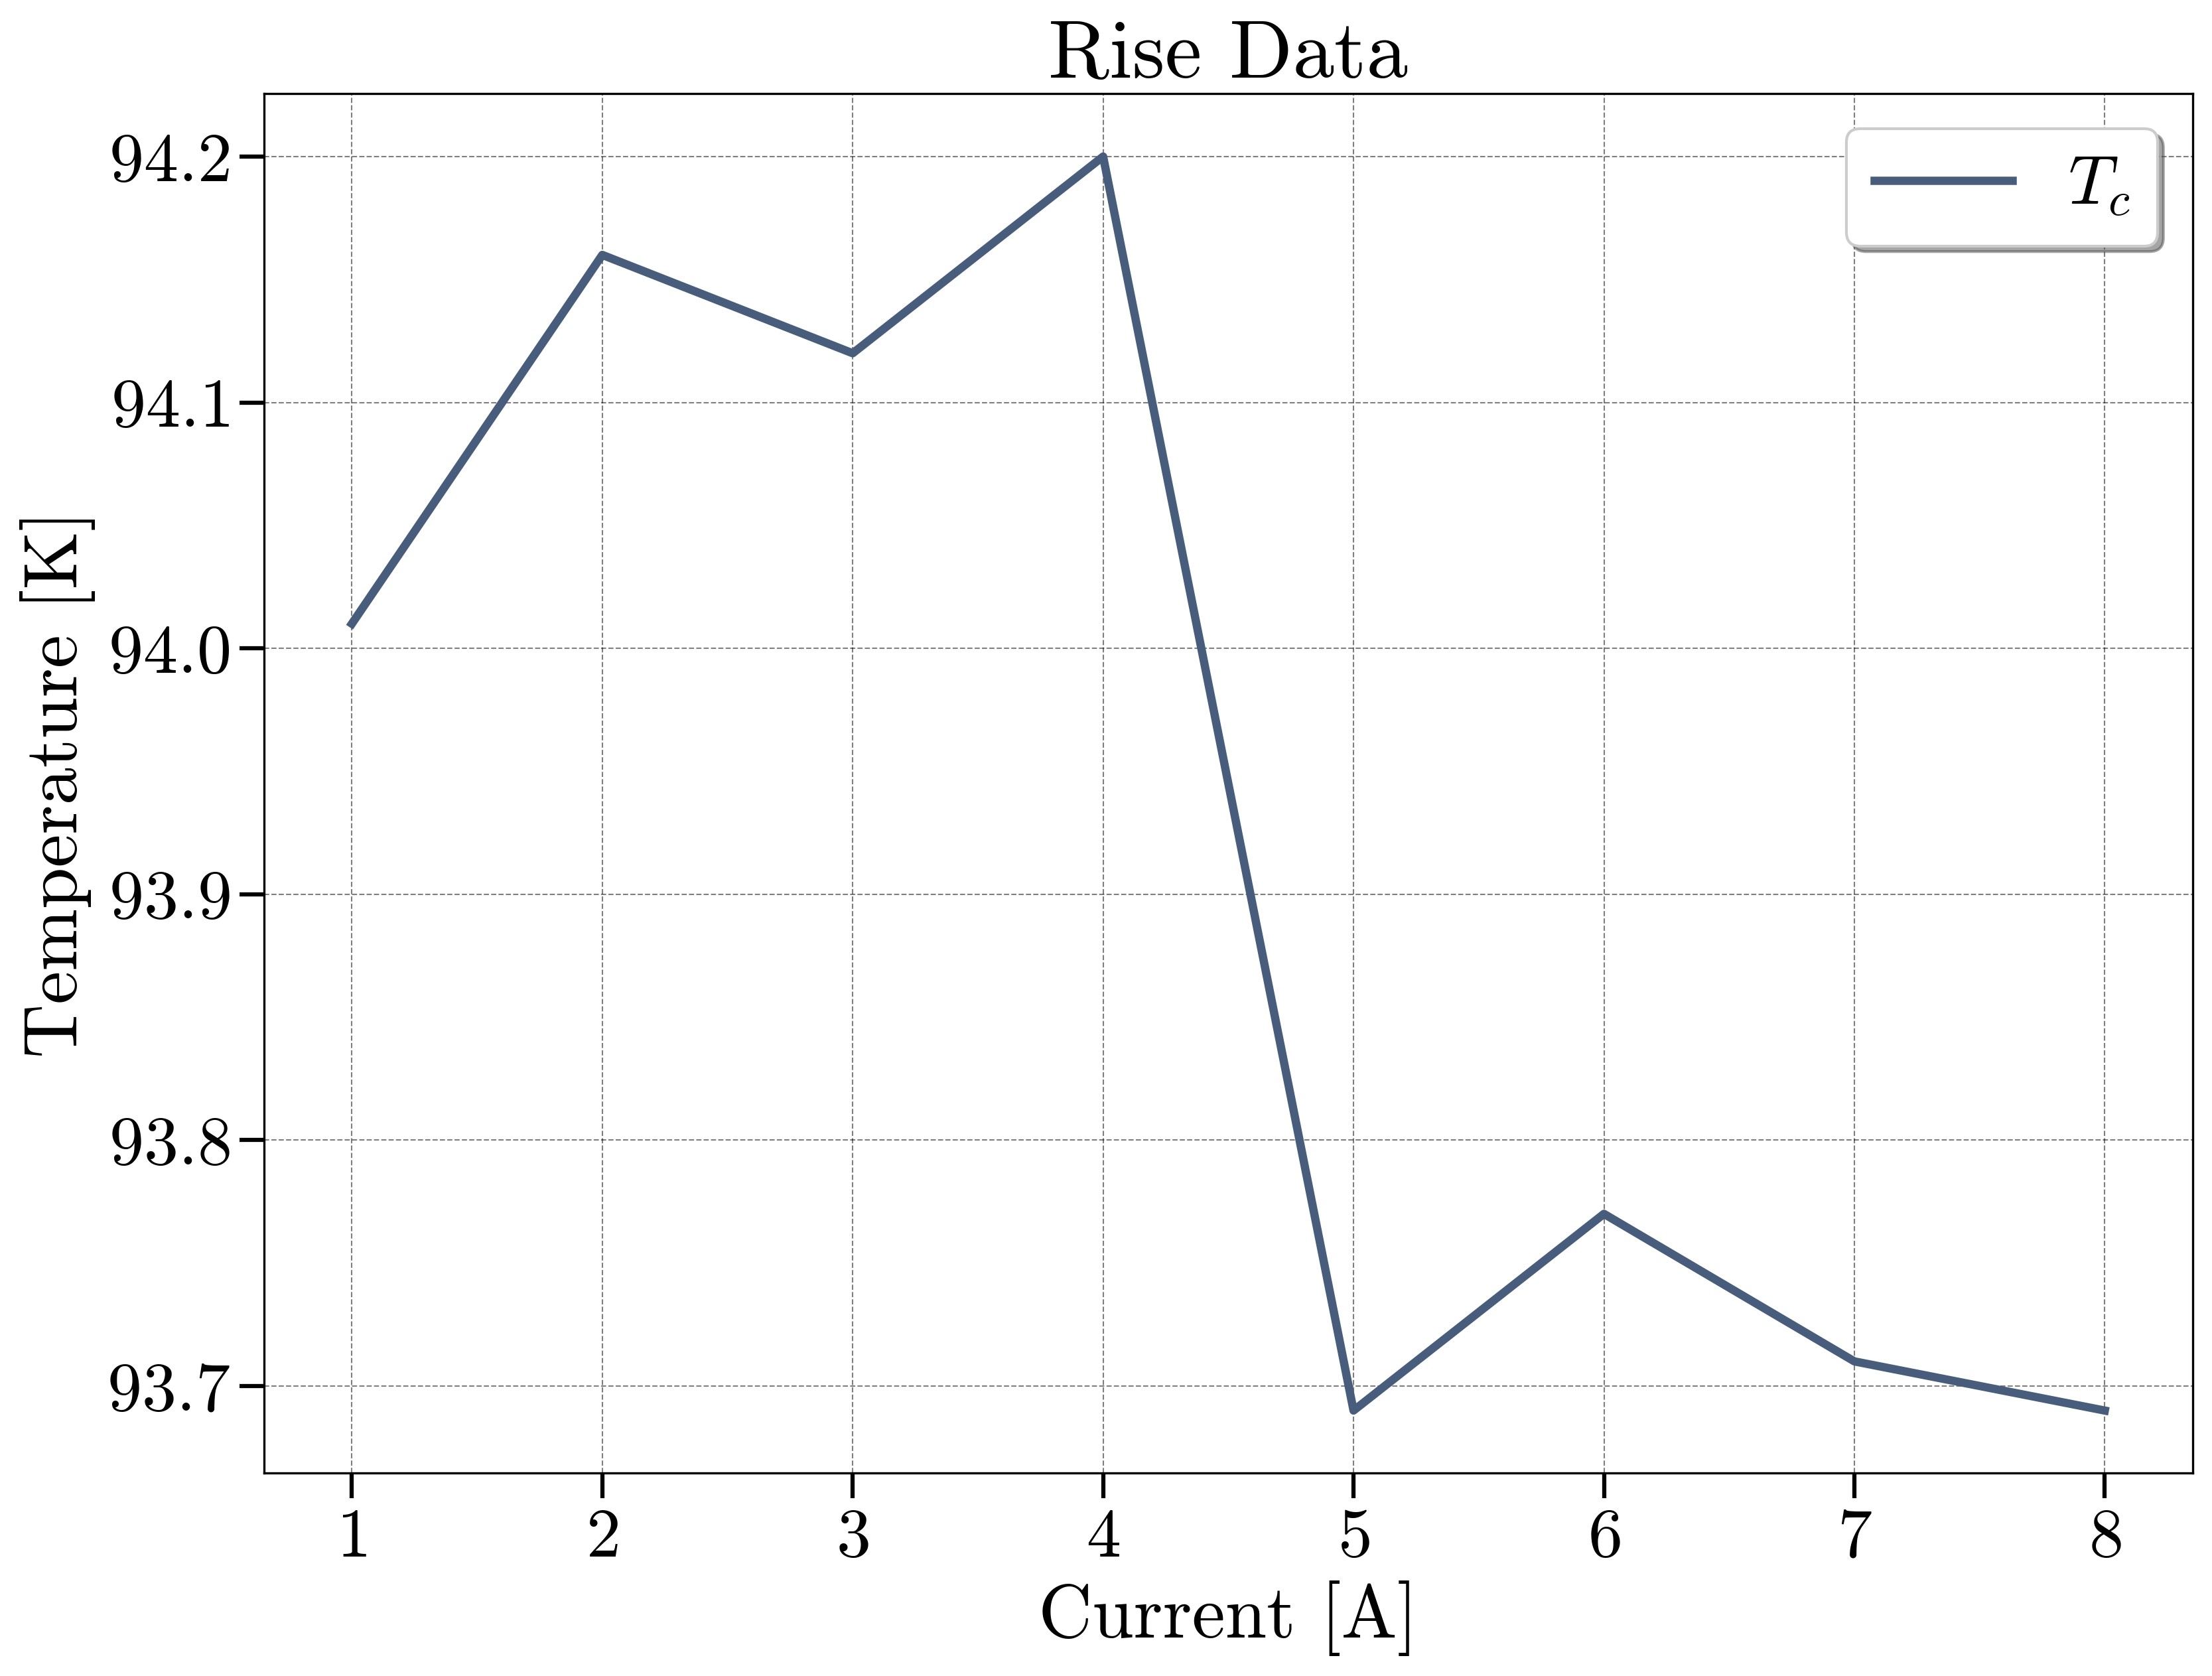

In [11]:
rise_data_list = []
for current in range(1, 9):
    rise_data_list.append(pd.read_csv('data/'+str(current)+'A上升.xls', encoding='latin1', sep='\t', skiprows=2, usecols=[0, 1], names=['R(V)', 'T(K)']))

rise_change_point = []
for rise_data in rise_data_list:
    algo = rpt.Dynp(model="l2").fit(rise_data['R(V)'].values)
    result = algo.predict(n_bkps=1)
    rise_change_point.append(rise_data['T(K)'].values[result[0]])

rise_change_point = np.array(rise_change_point)
current = np.array([1, 2, 3, 4, 5, 6, 7, 8])
ypu.plot(
    current, rise_change_point, '$T_c$', 
    'Rise Data', 'Current [A]', 'Temperature [K]'
)

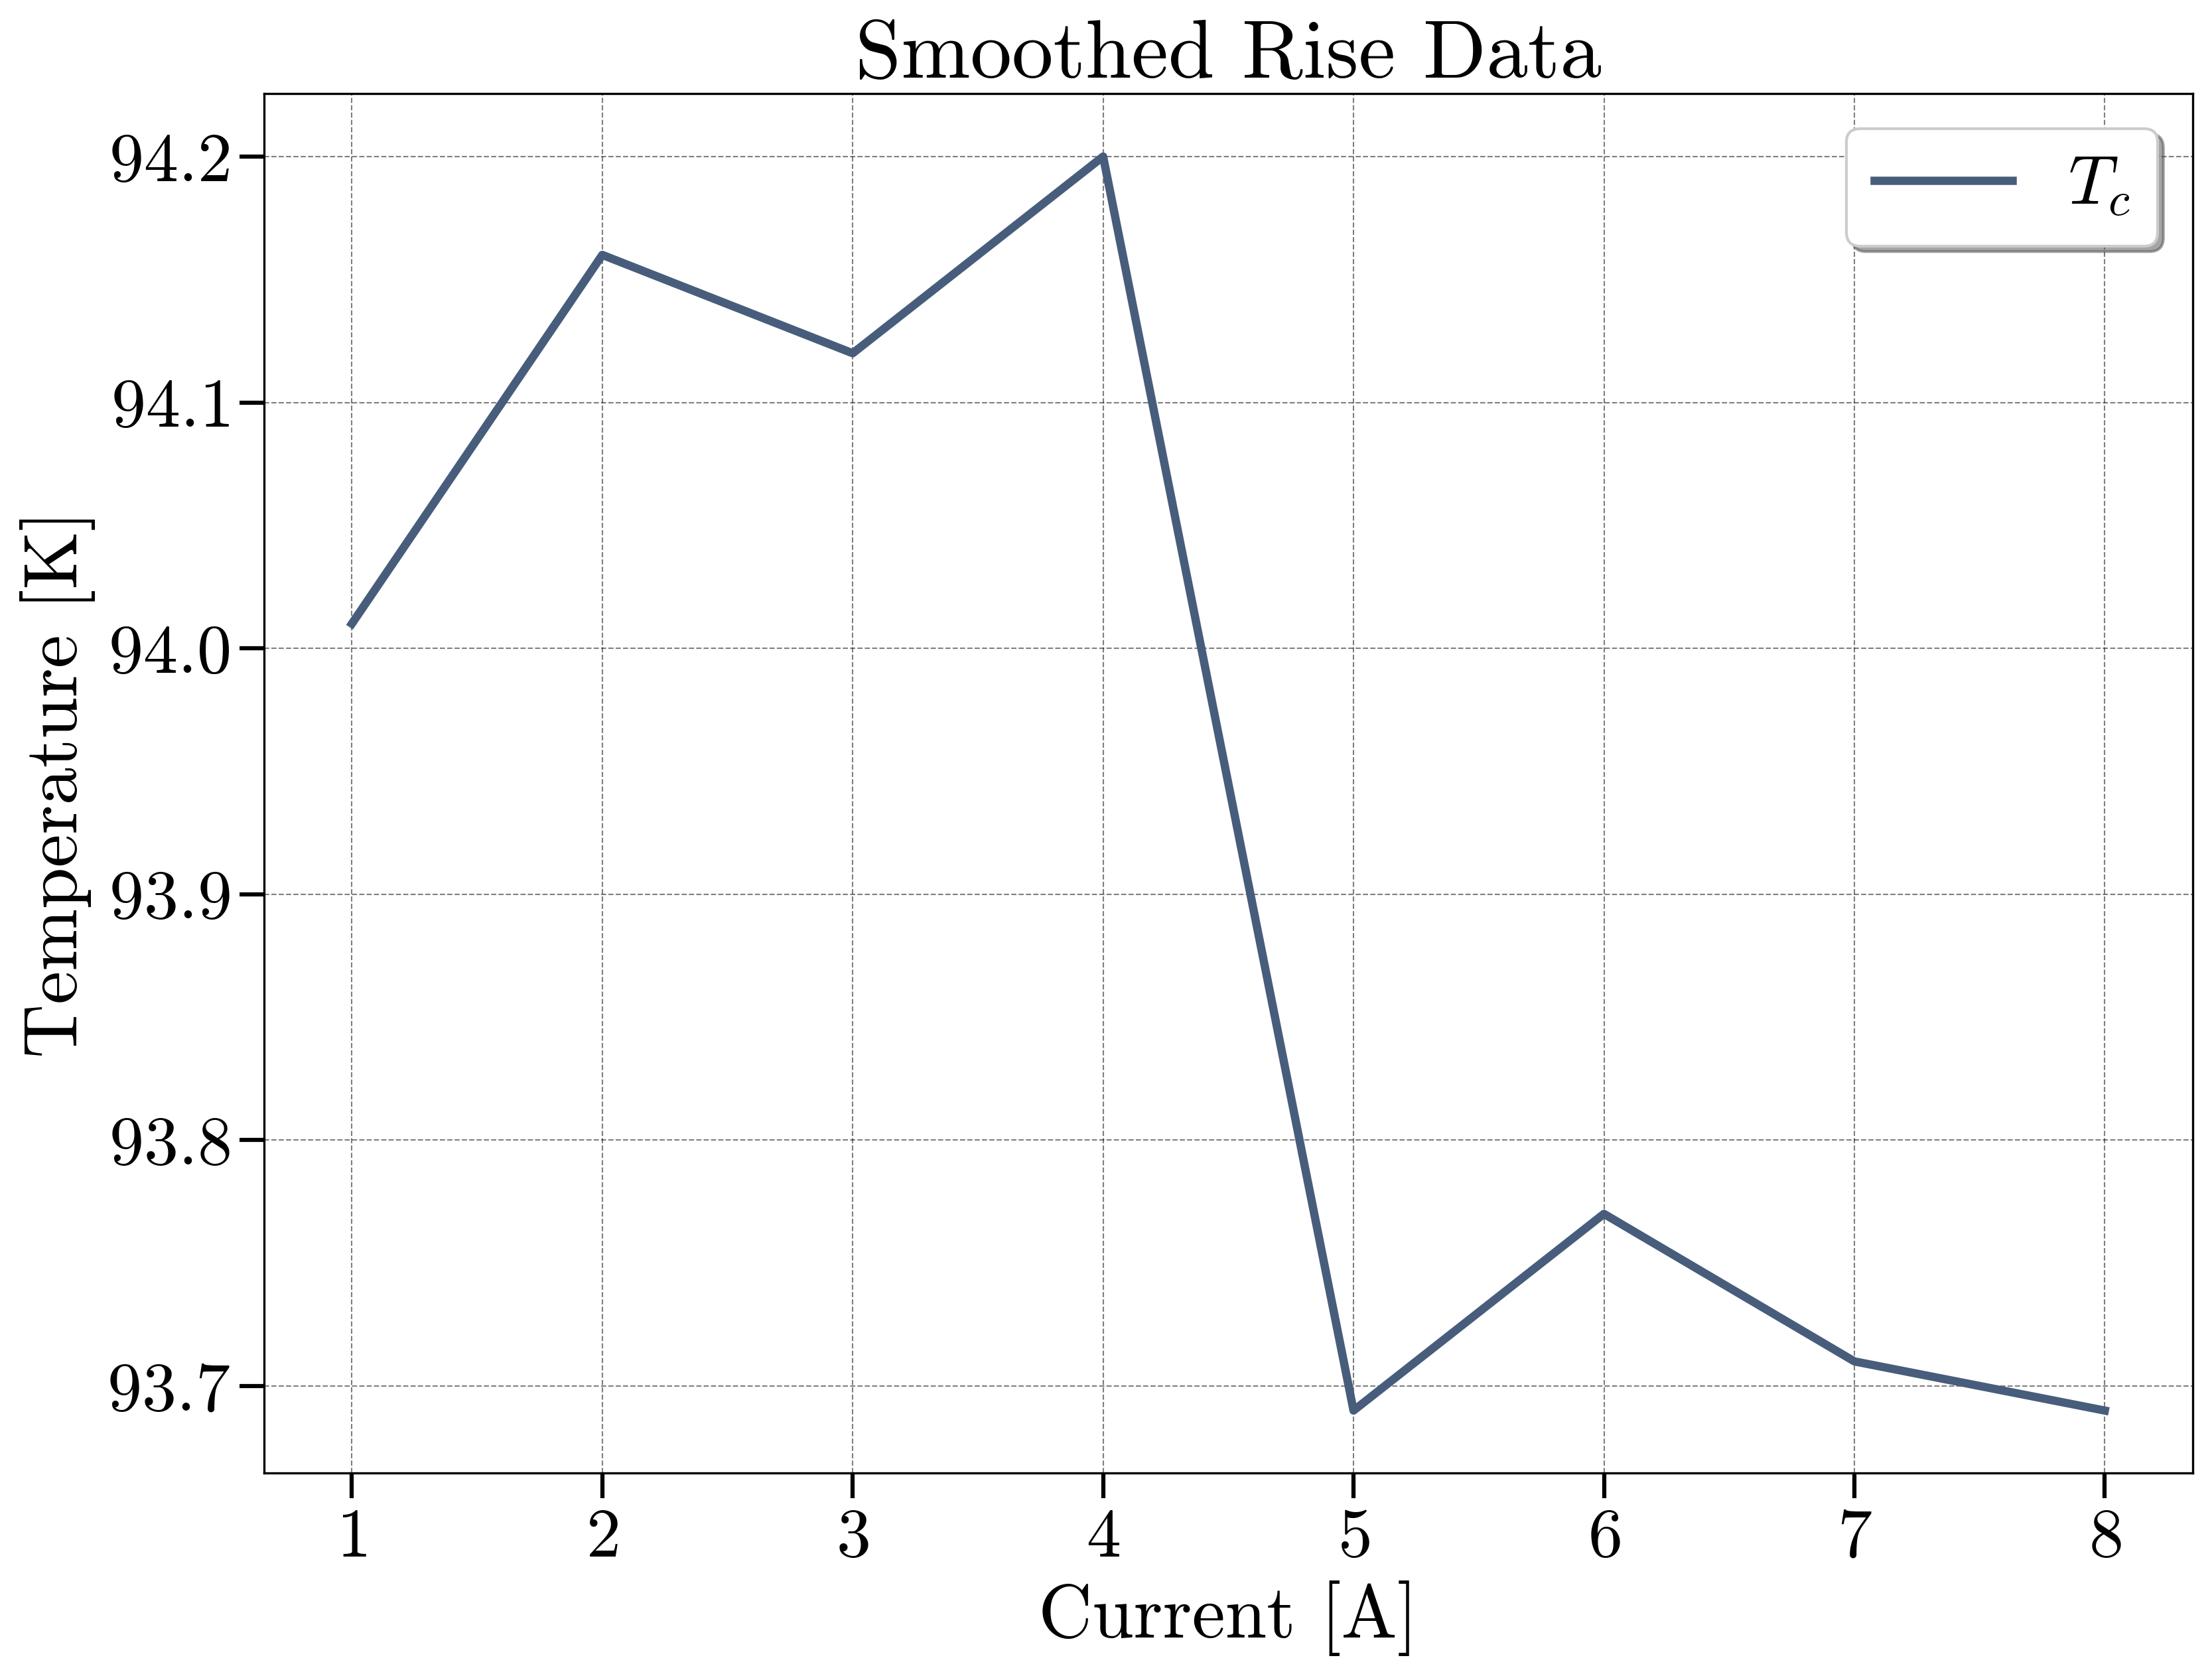

In [14]:
# 考虑滤波

from scipy.signal import savgol_filter
rise_data_list = []
for current in range(1, 9):
    rise_data_list.append(pd.read_csv('data/'+str(current)+'A上升.xls', encoding='latin1', sep='\t', skiprows=2, usecols=[0, 1], names=['R(V)', 'T(K)']))

rise_change_point = []
for rise_data in rise_data_list:
    algo = rpt.Dynp(model="l2").fit(savgol_filter(rise_data['R(V)'].values, window_length=51, polyorder=2))
    result = algo.predict(n_bkps=1)
    rise_change_point.append(rise_data['T(K)'].values[result[0]])

rise_change_point = np.array(rise_change_point)
current = np.array([1, 2, 3, 4, 5, 6, 7, 8])
ypu.plot(
    current, rise_change_point, '$T_c$', 
    'Smoothed Rise Data', 'Current [A]', 'Temperature [K]'
)